In [0]:
#Import required libraries

import finnhub
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [0]:
#Use the Finnhub API key to pull stock news data
finnhub_client = finnhub.Client(api_key = 'd8vj5a9r01qgrv4opm20d8vj5a9r01qgrv4opm2g')

stock_news = finnhub_client.company_news('AAPL', _from = '2026-05-01', to = '2026-06-26')
stock_news_df = pd.DataFrame(stock_news)

In [0]:
stock_news_df['datetime'] = pd.to_datetime(stock_news_df['datetime'], unit='s')
stock_news_df['news_text'] = (stock_news_df['headline'].fillna("") + ". " + stock_news_df['summary'].fillna("")).str.strip()


In [0]:
stock_news_df = (stock_news_df[stock_news_df['news_text'].str.len() > 5].drop_duplicates(subset = 'headline').sort_values('datetime').reset_index(drop=True))

In [0]:
print(f"{len(stock_news_df)} unique articles after cleaning")
stock_news_df[["datetime", "source", "headline"]].head()

247 unique articles after cleaning


,datetime,source,headline
0,2026-06-24 21:30:55,Yahoo,The memory chip crunch is paying off for this ...
1,2026-06-24 21:40:00,Yahoo,"Verizon Just Got Kicked Out of the Dow, but It..."
2,2026-06-25 01:02:28,Benzinga,Gary Black Says Tesla Stock Continues To Under...
3,2026-06-25 04:37:09,Benzinga,Exclusive: Trump’s Intel Push Won’t Kill TSMC—...
4,2026-06-25 08:43:50,Benzinga,"'Apple Raises Prices on Macs, iPads by $200 or..."


In [0]:
import torch
from transformers import AutoTokenizer, AutoModelForSequenceClassification

MODEL_NAME = 'ProsusAI/finbert'
device = "cuda" if torch.cuda.is_available() else "cpu"

/local_disk0/.ephemeral_nfs/envs/pythonEnv-4546976b-96a7-49b5-9aa4-a07e3dd8ae37/lib/python3.12/site-packages/torch/_vmap_internals.py:9: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  from torch.utils._pytree import _broadcast_to_and_flatten, tree_flatten, tree_unflatten


In [0]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME).to(device).eval()

id2label = model.config.id2label
label2id = {v.lower() : k for k, v in id2label.items()}

pos_i, neg_i, neu_i = label2id['positive'], label2id['negative'], label2id['neutral']
print("Label map:", id2label, "|device:", device)

config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  438MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  438MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Label map: {0: 'positive', 1: 'negative', 2: 'neutral'} |device: cpu


In [0]:
@torch.no_grad()
def score_texts(texts, batch_size = 16, max_length = 512):
    out = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i : i + batch_size]
        enc = tokenizer(
            batch, return_tensors='pt', padding=True,
            truncation=True, max_length=max_length).to(device)
        logits = model(**enc).logits
        out.append(torch.softmax(logits, dim=-1).cpu().numpy())
    return np.vstack(out)

probs = score_texts(stock_news_df['news_text'].tolist())

stock_news_df['prob_positive'] = probs[:, pos_i]
stock_news_df['prob_negative'] = probs[:, neg_i]
stock_news_df['prob_neutral'] = probs[:, neu_i]
stock_news_df['sentiment'] = [id2label[i] for i in probs.argmax(axis=1)]

stock_news_df['Sentiment_Score'] = stock_news_df['prob_positive'] - stock_news_df['prob_negative']


In [0]:
counts = stock_news_df['sentiment'].value_counts()
share = (counts / counts.sum()).round(3)

print("Sentiment counts:\n", counts.to_string())
print("\nSentiment share:\n", share.to_string())
print(f"\nMean signed score: {stock_news_df['Sentiment_Score'].mean():.3f}")
print(f"Median signed score: {stock_news_df['Sentiment_Score'].median():.3f}")
print(f"Net positive ratio (pos - neg): {(counts.get('positive',0) - counts.get('negative',0)) / counts.sum():.3f}")

Sentiment counts:
 sentiment
negative    138
neutral      68
positive     41

Sentiment share:
 sentiment
negative    0.559
neutral     0.275
positive    0.166

Mean signed score: -0.340
Median signed score: -0.507
Net positive ratio (pos - neg): -0.393


In [0]:
daily = (stock_news_df.set_index('datetime').resample("D")['Sentiment_Score'].agg(mean = 'mean', n = 'count').dropna())

In [0]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# order = ["positive", "neutral", "negative"]
# colors = {"positive": "#2e7d32", "neutral": "#9e9e9e", "negative": "#c62828"}
# counts.reindex(order).fillna(0).plot(
#     kind="bar", ax=axes[0], color=[colors[s] for s in order]
# )
# axes[0].set_title(f"{TICKER} — News sentiment distribution")
# axes[0].set_xlabel("")
# axes[0].tick_params(axis="x", rotation=0)

# axes[1].plot(daily.index, daily["mean"], marker="o", color="#1565c0")
# axes[1].axhline(0, color="grey", lw=0.8, ls="--")
# axes[1].set_title(f"{TICKER} — Daily mean signed sentiment")
# axes[1].set_ylabel("signed score (pos − neg)")
# axes[1].tick_params(axis="x", rotation=45)

# plt.tight_layout()
# plt.show()   # if nothing renders on your runtime, use: display(fig)

In [0]:
import warnings; warnings.filterwarnings('ignore')
import torch.nn as nn
import yfinance as yf

from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

##CONFIG
TICKER        = "AAPL"     # change me
LOOKBACK      = "3y"       # history pulled from yfinance
HORIZON       = 7          # forecast days ahead
TEST_DAYS     = 60         # one-step backtest holdout
LSTM_WINDOW   = 15         # sequence length for LSTM
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)


device: cpu


In [0]:

np.random.seed(42)
torch.manual_seed(42)


raw_data = yf.download(TICKER, period = LOOKBACK, auto_adjust = True, progress = False)
if isinstance(raw_data.columns, pd.MultiIndex):
    raw_data.columns = raw_data.columns.get_level_values(0)
raw_data = raw_data.rename(columns = str.lower)[["open","high","low","close","volume"]].dropna()
raw_data.index = pd.to_datetime(raw_data.index)

close = raw_data['close'].astype('float')
volume = raw_data['volume'].astype('float')

print(f"{len(raw_data)} trading days | {raw_data.index.min().date()} -> {raw_data.index.max().date()}")
raw_data.tail()

753 trading days | 2023-07-10 -> 2026-07-09


Price,open,high,low,close,volume
Date,,,,,
2026-07-02,294.119995,309.420013,293.679993,308.630005,75352800
2026-07-06,307.359985,314.200012,307.000000,312.660004,53590000
2026-07-07,315.290009,315.480011,310.149994,310.660004,42490000
2026-07-08,311.910004,314.820007,307.049988,313.390015,41323500
2026-07-09,310.445007,316.529999,308.160004,316.220001,44882363


In [0]:
if "daily" in globals() and isinstance(daily, pd.DataFrame) and "mean" in daily.columns:
    sent_src = daily['mean'].copy()
    sent_src.index = pd.to_datetime(sent_src.index)
    print(f"Using sentiment from prior notebook: {len(sent_src)} days")
else:
    sent_src = pd.Series(dtype=float)
    print('No daily sentiment found - running with neural sentiment (has_sentiment = 0)')

sentiment = sent_src.reindex(close.index)
has_sentiment = sentiment.notna().astype('float')

sentiment = sentiment.ffill().fillna(0.0)

print(f"Days with real sentiment: {int(has_sentiment.sum())} / {len(has_sentiment)}")

Using sentiment from prior notebook: 3 days
Days with real sentiment: 3 / 753


In [0]:
def compute_features(close, volume, sent, has_sent):
    f = pd.DataFrame(index = close.index)
    r = np.log(close).diff()

    #Lagged returns + rolling vol
    f['ret_1'] = r
    f['ret_2'] = r.shift(1)
    f['ret_3'] = r.shift(2)
    f['ret_5'] = r.shift(4)
    f['roll_mean_5'] = r.rolling(5).mean()
    f['roll_std_5'] = r.rolling(5).std()
    f['roll_std_10'] = r.rolling(10).std()

    #Price Relative to moving averages
    f['sma_ratio_10'] = close / close.rolling(10).mean() - 1
    f['sma_ratio_10'] = close / close.rolling(20).mean() - 1

    #RSI(14)
    d = close.diff()
    gain = d.clip(lower=0).rolling(14).mean()
    loss = (-d.clip(upper = 0)).rolling(14).mean()
    rs = gain / (loss + 1e-9)
    f['rsi_14'] = 100 - 100 / (1 + rs)

    #MACD
    macd = close.ewm(span = 12, adjust = False).mean() - close.ewm(span = 26, adjust = False).mean()
    f['macd'] = macd
    f['macd_signal'] = macd.ewm(span=9, adjust = False).mean()
    f['macd_hist'] = f['macd'] - f['macd_signal']

    #Volume zscore
    vlog = np.log(volume.replace(0, np.nan)).ffill()
    f['vol_z'] = (vlog - vlog.rolling(20).mean()) / (vlog.rolling(20).std() + 1e-9)

    #Calendar (weekly cycle)
    dow = close.index.dayofweek
    f['dow_sin'] = np.sin(2 * np.pi * dow / 5)
    f['dow_cos'] = np.cos(2 * np.pi * dow / 5)

    #Sentiment - Net positive signal from FinBERT, known at close of day t
    f['net_sentiment'] = sent
    f['sent_roll_3'] = sent.rolling(3).mean()
    f['has_sentiment'] = has_sent
    
    return f

F = compute_features(close, volume, sentiment, has_sentiment)
feat_cols = list(F.columns)
print(f"{len(feat_cols)} features:", feat_cols)
F.tail(3)


18 features: ['ret_1', 'ret_2', 'ret_3', 'ret_5', 'roll_mean_5', 'roll_std_5', 'roll_std_10', 'sma_ratio_10', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'vol_z', 'dow_sin', 'dow_cos', 'net_sentiment', 'sent_roll_3', 'has_sentiment']


,ret_1,ret_2,ret_3,ret_5,roll_mean_5,roll_std_5,roll_std_10,sma_ratio_10,rsi_14,macd,macd_signal,macd_hist,vol_z,dow_sin,dow_cos,net_sentiment,sent_roll_3,has_sentiment
Date,,,,,,,,,,,,,,,,,,
2026-07-07,-0.006417,0.012973,0.047272,0.026687,0.019543,0.019637,0.030446,0.052942,59.541672,1.947661,-0.06125,2.008911,-0.789124,0.951057,0.309017,-0.425921,-0.425921,0.0
2026-07-08,0.008749,-0.006417,0.012973,0.017200,0.015955,0.019644,0.030078,0.060066,59.492834,2.970296,0.54506,2.425237,-0.774420,0.587785,-0.809017,-0.425921,-0.425921,0.0
2026-07-09,0.008990,0.008749,-0.006417,0.047272,0.014313,0.019856,0.029857,0.065015,63.682988,3.963411,1.22873,2.734681,-0.538470,-0.587785,-0.809017,-0.425921,-0.425921,0.0


In [0]:
F.columns

Index(['ret_1', 'ret_2', 'ret_3', 'ret_5', 'roll_mean_5', 'roll_std_5',
       'roll_std_10', 'sma_ratio_10', 'rsi_14', 'macd', 'macd_signal',
       'macd_hist', 'vol_z', 'dow_sin', 'dow_cos', 'net_sentiment',
       'sent_roll_3', 'has_sentiment'],
      dtype='object')

In [0]:
returns = np.log(close).diff().rename('ret') #Target variable: next day log returns
X_all = F.shift(1)  #features of day t-1 to predict the returns of day t - This is to avoid the lookahead bias and make sure the model does not get future data
data = pd.concat([X_all, returns], axis = 1).dropna()
X, y = data[feat_cols], data['ret']  #Defining the features and target variable

split = X.index[-TEST_DAYS]
train = X.index < split
test = X.index >= split
X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]

#Actual prices realigned for testing returns for price-space scoring
#We dont need to look out for the look ahead bias so no need to shift the price data
price_prev = close.shift(1).reindex(y.index)
price_te = close.reindex(y_test.index)

print(f"train {X_train.shape[0]} | test {X_test.shape[0]} | split at {split.date()}")

train 673 | test 60 | split at 2026-04-14


In [0]:
def price_metrics(y_true_price, y_pred_price):
    return {
        'RMSE' : np.sqrt(mean_squared_error(y_true_price, y_pred_price)),
        'MAE' : mean_absolute_error(y_true_price, y_pred_price)
    }

def directional_accuracy(r_true, r_pred):
    return float((np.sign(r_true) == np.sign(r_pred)).mean())

results = {}  #model backtest metrics
forecasts = {} #model 7-day price path forecasts

##Naive random walk : tomorrow = today (zero predicted return)
naive_pred_price = price_prev.reindex(y_test.index)
m = price_metrics(price_te, naive_pred_price)
m['DirAcc'] = directional_accuracy(y_test, np.zeros_like(y_test))
results['Naive_RW'] = m
forecasts['Naive_RW'] = pd.Series(close.iloc[-1], index=None)
print("Naive Baseline", {k: round(v, 4) for k,v in m.items()})

Naive Baseline {'RMSE': np.float64(5.2232), 'MAE': 3.9684, 'DirAcc': 0.0}


In [0]:
def next_bday(d):
    return (pd.Timestamp(d) + pd.offsets.BDay(1)).normalize()

def recursive_forecast(predict_F, close0, vol0, sent0, has0, horizon):
    c, v, s, h = close0.copy(), vol0.copy(), sent0.copy(), has0.copy()
    med_vol = v.iloc[-20:].median()
    carry_s, carry_h = s.iloc[-1], h.iloc[-1]  #Carry Forward sentiment
    out = {}
    for _ in range(horizon):
        Fc = compute_features(c, v, s, h)
        rhat = float(predict_F(Fc))
        nd = next_bday(c.index[-1])
        np_ = c.iloc[-1] * np.exp(rhat)
        c.loc[nd], v.loc[nd], s.loc[nd], h.loc[nd] = np_, med_vol, carry_s, carry_h
        out[nd] = np_
    return pd.Series(out, name='price')

future_dates = [c for c in recursive_forecast(lambda F: 0.0, close, volume, sentiment, has_sentiment, HORIZON).index]

In [0]:
log_close = np.log(close)
exog_full = sentiment.shift(1).reindex(log_close.index).fillna(0.0).to_frame("sent")

sx_split = log_close.index[-TEST_DAYS]
endogenous_train = log_close[log_close.index < sx_split]
exogenous_train = exog_full[exog_full.index < sx_split]

try:
    sx = SARIMAX(endogenous_train, exog=exogenous_train, order=(2,1,2), enforce_stationarity=False, enforece_invertibility=False).fit(disp=False)
except Exception:
    sx = SARIMAX(endogenous_train, exog=exogenous_train, order=(1,1,1)).fit(disp=False)

#one step ahead backtest
sx_ext = sx.apply(log_close, exog = exog_full)
pred = sx_ext.get_prediction(start=sx_split, dynamic=False)
sx_pred_price = np.exp(pred.predicted_mean).reindex(y_test.index)
sx_pred_ret = np.log(sx_pred_price / price_prev.reindex(y_test.index))

m = price_metrics(price_te, sx_pred_price)
m['DirAcc'] = directional_accuracy(y_test, sx_pred_ret)
results['SARIMAX'] = m

#7 day forecastas - refit on all data, carry sentiment forward
sx_full = SARIMAX(log_close, exog=exog_full, order=(2,1,2), enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
fut_exog = pd.DataFrame({'sent':[exog_full['sent'].iloc[-1]]*HORIZON}, index=future_dates)
forecasts['SARIMAX'] = np.exp(sx_full.forecast(HORIZON, exog=fut_exog))
forecasts['SARIMAX'].index = future_dates

print("SARIMAX", {k: round(v, 4) for k,v in m.items()})

/local_disk0/.ephemeral_nfs/envs/pythonEnv-4546976b-96a7-49b5-9aa4-a07e3dd8ae37/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-4546976b-96a7-49b5-9aa4-a07e3dd8ae37/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-4546976b-96a7-49b5-9aa4-a07e3dd8ae37/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/local_disk0/.ephemeral_nfs/envs/pythonEnv-

SARIMAX {'RMSE': np.float64(5.2184), 'MAE': 4.005, 'DirAcc': 0.55}


/local_disk0/.ephemeral_nfs/envs/pythonEnv-4546976b-96a7-49b5-9aa4-a07e3dd8ae37/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/local_disk0/.ephemeral_nfs/envs/pythonEnv-4546976b-96a7-49b5-9aa4-a07e3dd8ae37/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


In [0]:
import pandas as pd
prophet_df = pd.DataFrame({'ds': close.index, 'y':close.values,
                           'sent': sentiment.shift(1).fillna(0).values})
prophet_train = prophet_df[prophet_df['ds'] < pd.Timestamp(split)]

def fit_prophet(frame):
    mdl = Prophet(growth='linear', seasonality_mode='multiplicative', changepoint_prior_scale=0.07)
    # Prophet(daily_seasonality=False, weekly_seasonality=True, yearly_seasonality=True, changepoint_prior_scale=0.07, seasonality_prior_scale=10)
    mdl.add_regressor('sent')
    mdl.fit(frame)
    return mdl

pm = fit_prophet(prophet_train)
fc_te = pm.predict(prophet_df[prophet_df['ds'] >= pd.Timestamp(split)][['ds', 'sent']])
pp = pd.Series(fc_te['yhat'].values, index = pd.to_datetime(fc_te['ds'])).reindex(y_test.index)
pp_ret = np.log(pp / price_prev.reindex(y_test.index))
m = price_metrics(price_te, pp)
m['DirAcc'] = directional_accuracy(y_test, pp_ret)
results['Prophet'] = m

#7 day forecast on full data
pm_full = fit_prophet(prophet_df)
fut = pd.DataFrame({'ds': future_dates, 'sent' : [prophet_df['sent'].iloc[-1]]*HORIZON})
fc = pm_full.predict(fut)
forecasts['Prophet'] = pd.Series(fc['yhat'].values, index = future_dates)
print('Prophet:', {k: round(v,4) for k, v in m.items()})

20:14:33 - cmdstanpy - INFO - Chain [1] start processing
20:14:35 - cmdstanpy - INFO - Chain [1] done processing
20:14:35 - cmdstanpy - INFO - Chain [1] start processing
20:14:36 - cmdstanpy - INFO - Chain [1] done processing


Prophet: {'RMSE': np.float64(25.4513), 'MAE': 17.897, 'DirAcc': 0.5167}


In [0]:
#XGBoost
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators = 400, learning_rate = 0.03, max_depth = 4, subsample = 0.8, colsample_bytree = 0.8, random_state = 42)
xgb.fit(X_train, y_train)

xgb_ret = pd.Series(xgb.predict(X_test), index = y_test.index)
xgb_price = price_prev.reindex(y_test.index) * np.exp(xgb_ret)

m = price_metrics(price_te, xgb_price)
m['DirAcc'] = directional_accuracy(y_test, xgb_ret)
results['XGBoost'] = m

forecasts['XGBoost'] = recursive_forecast(
    lambda F : xgb.predict(F[feat_cols].iloc[[-1]])[0], close, volume, sentiment, has_sentiment, HORIZON)
print('XGBoost', {k: round(v,4) for k,v in m.items()})

XGBoost {'RMSE': np.float64(5.6005), 'MAE': 4.4425, 'DirAcc': 0.4667}


In [0]:
#LightGBM
from lightgbm import LGBMRegressor
lgb = LGBMRegressor(n_estimators = 400, max_depth = 4, learning_rate = 0.03, subsample = 0.8, colsample_bytree = 0.8, random_state = 42, verbose = -1)
lgb.fit(X_train, y_train)

lgb_ret = pd.Series(lgb.predict(X_test), index = y_test.index)
lgb_price = price_prev.reindex(y_test.index) * np.exp(lgb_ret)

m = price_metrics(price_te, lgb_price)
m['DirAcc'] = directional_accuracy(y_test, lgb_ret)
results['LightGBM'] = m

forecasts['LightGBM'] = recursive_forecast(
    lambda F : lgb.predict(F[feat_cols].iloc[[-1]])[0], close, volume, sentiment, has_sentiment, HORIZON)
print('LightGBM', {k: round(v, 4) for k,v in m.items()})


LightGBM {'RMSE': np.float64(5.2816), 'MAE': 4.2185, 'DirAcc': 0.5333}


In [0]:
#GRU (small version of LSTM)
scaler = StandardScaler().fit(F.loc[X_train.index, feat_cols])
Fz = pd.DataFrame(scaler.transform(F[feat_cols]), index = F.index, columns = feat_cols)

# --- guard: shrink the window if history is short, skip if still too small ---
clean_rows = Fz.dropna().shape[0]
EFF_WINDOW = min(LSTM_WINDOW, max(5, clean_rows // 4))   # never larger than data supports
if EFF_WINDOW != LSTM_WINDOW:
    print(f"[LSTM] shrinking window {LSTM_WINDOW} -> {EFF_WINDOW} (only {clean_rows} clean rows)")

RUN_LSTM = clean_rows >= EFF_WINDOW + TEST_DAYS + 10     # enough for train+val+test?
if not RUN_LSTM:
    print(f"[LSTM] skipped: not enough data ({clean_rows} clean rows). "
          f"Increase LOOKBACK or lower TEST_DAYS.")

def make_sequences(Fz, returns, W):
    xs, ys, idx = [], [], []
    r = returns.reindex(Fz.index)
    for t in range(W - 1, len(Fz) - 1):
        seq = Fz.iloc[t-W+1:t+1].values
        tgt = r.iloc[t+1]
        if not np.isnan(seq).any() and not np.isnan(tgt):
            xs.append(seq)
            ys.append(tgt)
            idx.append(Fz.index[t+1])
    return np.array(xs), np.array(ys), pd.DatetimeIndex(idx)

Xs, ys, idx = make_sequences(Fz, returns, LSTM_WINDOW)
mask_train = idx < pd.Timestamp(split)
val_cut = int(mask_train.sum() * 0.85) #last 15% of train data for validation
Xtr, ytr = Xs[:val_cut], ys[:val_cut]
Xval, yval = Xs[val_cut:mask_train.sum()], ys[val_cut:mask_train.sum()]
Xte_s, yte_s, idx_s = Xs[~mask_train], ys[~mask_train], idx[~mask_train]

class GRUReg(nn.Module):
    def __init__(self, n_feat, hidden=32):
        super().__init__()
        self.GRU = nn.GRU(n_feat, hidden, batch_first = True)
        self.head = nn.Sequential(nn.Dropout(0.2), nn.Linear(hidden, 1))
    def forward(self, x):
        o, _ = self.GRU(x)
        return self.head(o[:, -1]).squeeze(-1)

def to_t(a):
    return torch.tensor(a, dtype = torch.float32, device = DEVICE)

net = GRUReg(len(feat_cols)).to(DEVICE)
opt = torch.optim.Adam(net.parameters(), lr = 1e-3)
lossf = nn.MSELoss()
best, best_state, patience = np.inf, None, 0
for ep in range(2000):
    net.train()
    opt.zero_grad()
    loss = lossf(net(to_t(Xtr)), to_t(ytr))
    loss.backward()
    opt.step()
    net.eval()
    with torch.no_grad():
        vl = lossf(net(to_t(Xval)), to_t(yval)).item()
    if vl < best - 1e-7 : best, best_state, patience = vl, net.state_dict(), 0
    else:
        patience += 1
        if patience >= 20 : break
net.load_state_dict(best_state)
net.eval()

with torch.no_grad():
    gru_ret = pd.Series(net(to_t(Xte_s)).cpu().numpy(), index = idx_s).reindex(y_test.index)
gru_price = price_prev.reindex(y_test.index) * np.exp(gru_ret)
valid = gru_price.dropna().index
m = price_metrics(price_te.reindex(valid), gru_price.reindex(valid))
m['DirAcc'] = directional_accuracy(y_test.reindex(valid), gru_ret.reindex(valid))
results['GRU'] = m

def gru_predict_F(Fc):
    z = scaler.transform(Fc[feat_cols].iloc[-LSTM_WINDOW:].values)
    with torch.no_grad():
        return float(net(to_t(z[None, ...]))[0])

forecasts['GRU'] = recursive_forecast(
    gru_predict_F, close, volume, sentiment, has_sentiment, HORIZON
)

print('GRU:', {k: round(v,4) for k,v in m.items()})

        




GRU: {'RMSE': np.float64(7.9513), 'MAE': 6.436, 'DirAcc': 0.5667}


In [0]:
results

{'Naive_RW': {'RMSE': np.float64(5.223164088982668),
  'MAE': 3.968367004394531,
  'DirAcc': 0.0},
 'SARIMAX': {'RMSE': np.float64(5.218410560391243),
  'MAE': 4.004997761385572,
  'DirAcc': 0.55},
 'Prophet': {'RMSE': np.float64(25.451273681031676),
  'MAE': 17.896999145803743,
  'DirAcc': 0.5166666666666667},
 'XGBoost': {'RMSE': np.float64(5.600490252063787),
  'MAE': 4.442529200847457,
  'DirAcc': 0.4666666666666667},
 'LightGBM': {'RMSE': np.float64(5.281575160999374),
  'MAE': 4.218495876066345,
  'DirAcc': 0.5333333333333333},
 'GRU': {'RMSE': np.float64(7.9513439085379485),
  'MAE': 6.4360090360635995,
  'DirAcc': 0.5666666666666667}}

In [0]:
#Backtest comparison table
forecasts['Naive_RW'] = pd.Series(close.iloc[-1], index=future_dates)

comp = pd.DataFrame(results).T[['RMSE', 'MAE', 'DirAcc']].sort_values('RMSE')
comp['beats_naive'] = comp['RMSE'] < results['Naive_RW']['RMSE']

print("=== One-step backtest (lower RMSE/MAE better; DirAcc > 0.5 better) ===")
display(comp.round(4))

=== One-step backtest (lower RMSE/MAE better; DirAcc > 0.5 better) ===


RMSE,MAE,DirAcc,beats_naive
5.2184,4.005,0.55,true
5.2232,3.9684,0.0,false
5.2816,4.2185,0.5333,false
5.6005,4.4425,0.4667,false
7.9513,6.436,0.5667,false
25.4513,17.897,0.5167,false


Last actual close (2026-07-09): 316.22



Naive_RW,SARIMAX,Prophet,XGBoost,LightGBM,GRU,Ensemble
316.22,316.6,312.06,315.85,315.75,325.03,317.06
316.22,317.11,314.81,315.91,317.02,331.4,319.25
316.22,317.09,315.34,314.78,318.61,336.44,320.45
316.22,316.89,315.78,314.29,317.53,350.46,322.99
316.22,316.85,315.27,312.4,317.14,374.36,327.2
316.22,316.92,315.18,309.07,313.72,404.55,331.89
316.22,316.95,314.15,308.99,310.68,433.75,336.9


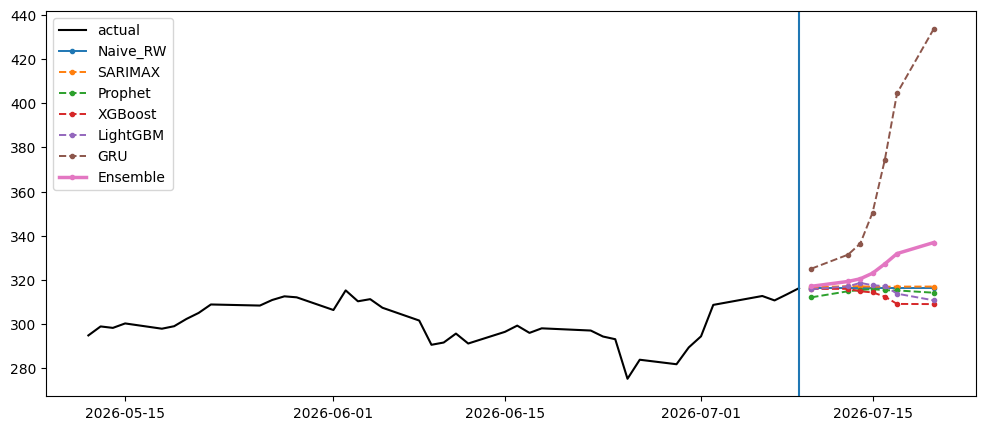

In [0]:
fc_df = pd.DataFrame(forecasts).reindex(future_dates)
model_cols = [c for c in fc_df.columns if c != "Naive_RW"]

fc_df['Ensemble'] = fc_df[model_cols].mean(axis=1)  #Simple mean = robust default

print(f"Last actual close ({close.index[-1].date()}): {close.iloc[-1]:.2f}\n")
display(fc_df.round(2))

plt.figure(figsize=(12,5))
plt.plot(close.index[-40:], close.iloc[-40:], color='black', label='actual')
for col in fc_df.columns:
    style = "--" if col not in ("Ensemble", "Naive_RW") else "-"
    lw = 2.5 if col=='Ensemble' else 1.4
    plt.plot(fc_df.index, fc_df[col], style, marker='o', ms = 3, lw=lw, label=col)

plt.axvline(close.index[-1], )
plt.legend()

Last actual close (2026-07-09): 316.22



Naive_RW,SARIMAX,Prophet,XGBoost,LightGBM,GRU,Ensemble
316.22,316.6,312.06,315.85,315.75,325.03,317.06
316.22,317.11,314.81,315.91,317.02,331.4,319.25
316.22,317.09,315.34,314.78,318.61,336.44,320.45
316.22,316.89,315.78,314.29,317.53,350.46,322.99
316.22,316.85,315.27,312.4,317.14,374.36,327.2
316.22,316.92,315.18,309.07,313.72,404.55,331.89
316.22,316.95,314.15,308.99,310.68,433.75,336.9


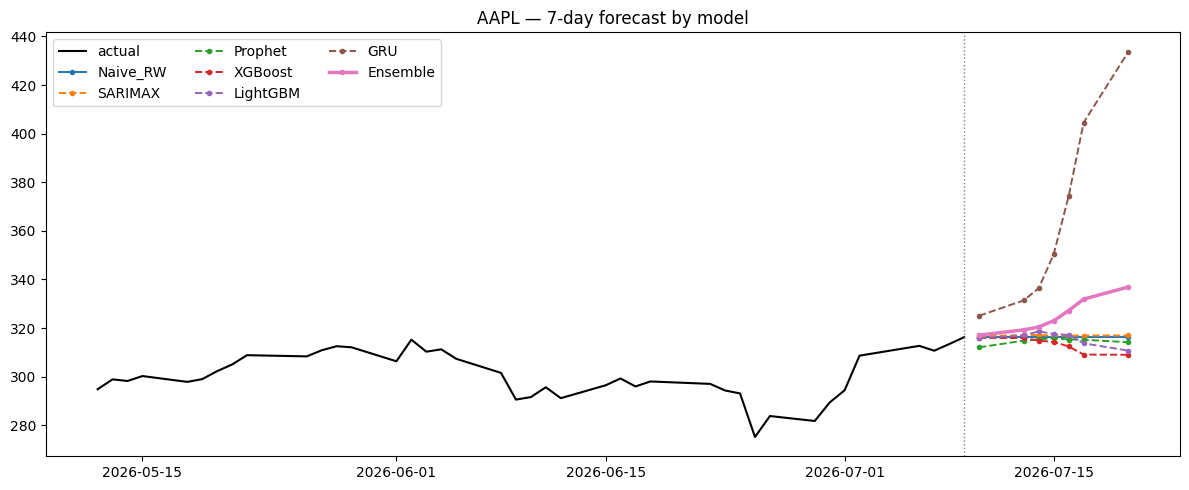

In [0]:
fc_df = pd.DataFrame(forecasts).reindex(future_dates)
model_cols = [c for c in fc_df.columns if c != "Naive_RW"]
fc_df["Ensemble"] = fc_df[model_cols].mean(axis=1)   # simple mean = robust default

print(f"Last actual close ({close.index[-1].date()}): {close.iloc[-1]:.2f}\n")
display(fc_df.round(2))

plt.figure(figsize=(12,5))
plt.plot(close.index[-40:], close.iloc[-40:], color="black", label="actual")
for col in fc_df.columns:
    style = "--" if col not in ("Ensemble","Naive_RW") else "-"
    lw = 2.5 if col=="Ensemble" else 1.4
    plt.plot(fc_df.index, fc_df[col], style, marker="o", ms=3, lw=lw, label=col)
plt.axvline(close.index[-1], color="grey", ls=":", lw=1)
plt.title(f"{TICKER} — {HORIZON}-day forecast by model"); plt.legend(ncol=3); plt.tight_layout()
plt.show()   # if blank on your runtime: display(plt.gcf())

In [0]:

from arch import arch_model

r_pct = (np.log(close).diff().dropna() * 100)     # arch prefers percent returns
g = arch_model(r_pct, mean="Constant", vol="GARCH", p=1, q=1, dist="t").fit(disp="off")
gf = g.forecast(horizon=HORIZON, reindex=False)
sigma_daily = np.sqrt(gf.variance.values[-1]) / 100        # back to decimal
cum_sigma = np.sqrt(np.cumsum(sigma_daily**2))             # vol scales with sqrt(time)

center = fc_df["Ensemble"].values
band = pd.DataFrame({
    "forecast": center,
    "lower_95": center * np.exp(-1.96*cum_sigma),
    "upper_95": center * np.exp(+1.96*cum_sigma),
}, index=future_dates)
display(band.round(2))

forecast,lower_95,upper_95
317.06,306.73,327.73
319.25,304.59,334.61
320.45,302.47,339.5
322.99,302.11,345.32
327.2,303.59,352.66
331.89,305.69,360.33
336.9,308.22,368.25


In [0]:
fc_df

,Naive_RW,SARIMAX,Prophet,XGBoost,LightGBM,GRU,Ensemble
2026-07-10,316.220001,316.596969,312.060791,315.854010,315.745233,325.030910,317.057583
2026-07-13,316.220001,317.106872,314.812861,315.906247,317.022297,331.397509,319.249157
2026-07-14,316.220001,317.088807,315.344356,314.783871,318.606080,336.439516,320.452526
2026-07-15,316.220001,316.892719,315.782594,314.287285,317.531549,350.463890,322.991607
2026-07-16,316.220001,316.851908,315.268001,312.404100,317.138830,374.358886,327.204345
2026-07-17,316.220001,316.915663,315.183898,309.066483,313.715195,404.549115,331.886071
2026-07-20,316.220001,316.946485,314.147107,308.988319,310.677539,433.748178,336.901526


In [0]:
from gym_anytrading.envs import StocksEnv
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv

def add_signals(env):
    start = env.frame_bound[0] - env.window_size
    end = env.frame_bound[1]
    prices = env.df.loc[:, "Close"].to_numpy()[start:end]

    sentiment = env.df.loc[:, "sentiment"].to_numpy()[start:end]
    ml_forecast = env.df.loc[:, "ml_forecast"].to_numpy()[start:end]

    # z-score normalize the custom signals so they're on a comparable scale to price
    def zscore(x):
        std = x.std()
        return (x - x.mean()) / std if std > 0 else x * 0

    signal_features = np.column_stack((
        prices,
        zscore(sentiment),
        zscore(ml_forecast),
    ))
    return prices, signal_features


class MyCustomEnv(StocksEnv):
    _process_data = add_signals


In [0]:
WINDOW_SIZE = 12
TRAIN_END = int(len(df) * 0.8)

env_train = MyCustomEnv(df=df, window_size=WINDOW_SIZE, frame_bound=(WINDOW_SIZE, TRAIN_END))
env_test = MyCustomEnv(df=df, window_size=WINDOW_SIZE, frame_bound=(TRAIN_END, len(df)))